#Fashin MNIST
Fashion Mnist는 옷, 바지 등 10가지 종류의 의류로 구성된 데이터입니다. 이 데이터는 (28, 28) 크기로 구성되어 있으며 Training Set 6만장, Test Set 1만장으로 총합 7만장으로 이루어져 있습니다. Keras에서 dataset을 import 할 수 있고, 처음 import 시 다운로드 하는 과정이 추가됩니다.

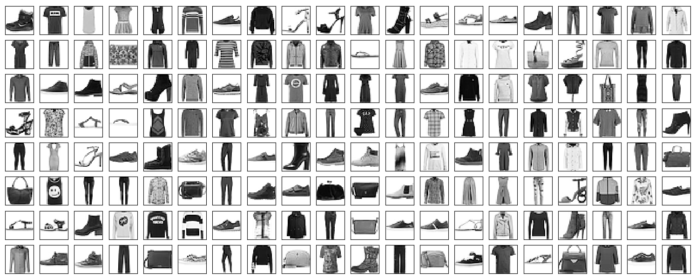


In [1]:
from tensorflow.keras import datasets, layers, models, utils
from tensorflow import keras
import numpy as np
import matplotlib.pyplot as plt

In [2]:
(x_train2d, y_train),(x_test2d, y_test) = datasets.fashion_mnist.load_data()

In [3]:
print(x_train2d.shape, y_train.shape)
print(x_test2d.shape, y_test.shape)

(60000, 28, 28) (60000,)
(10000, 28, 28) (10000,)


In [4]:
items = {0:'T-shirt/top', 1:'Trouser', 2:'Pullover', 3:'Dress',
         4:'Coat', 5:'Sandal', 6:'Shirt', 7:'Sneaker',
         8:'Bag', 9:'Ankel boot'}

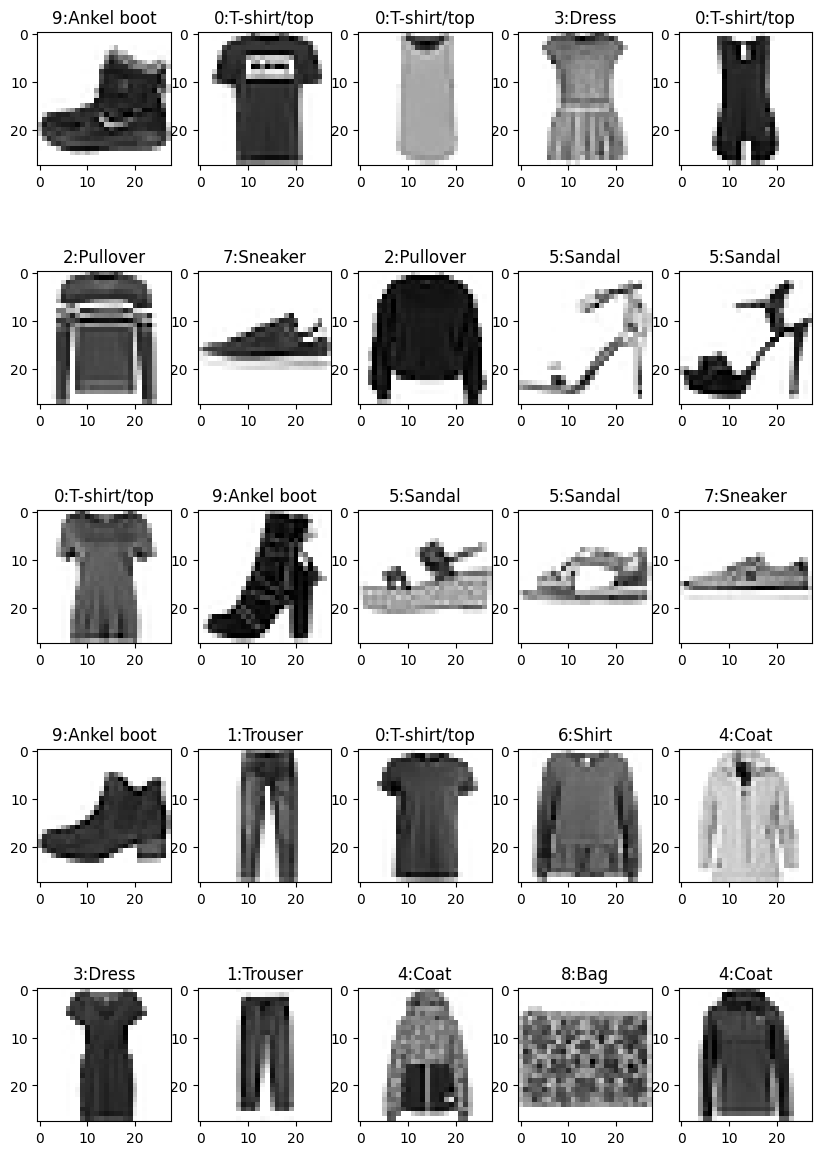

In [5]:
fig, axs = plt.subplots(5, 5, figsize=(10,15))
for i in range(5):
  for j in range(5):
    axs[i, j].set_title('{}:{}'.format(y_train[i*5+j], items[y_train[i*5+j]]))
    axs[i, j].imshow(x_train2d[i*5+j], cmap='gray_r')
plt.show()

In [6]:
x_train = x_train2d.reshape(-1, 28, 28, 1)
x_test = x_test2d.reshape(-1, 28, 28, 1)

In [7]:
x_train = x_train / 255
x_test = x_test / 255

#모델구성

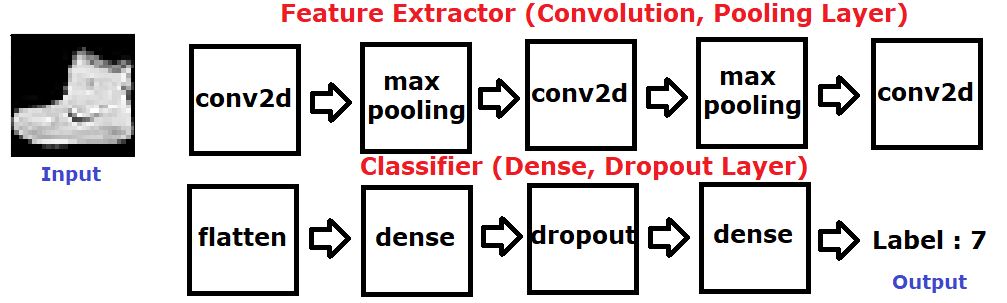

## Feature Extractor

In [8]:
model = models.Sequential()
model.add(layers.Conv2D(32, (3,3), padding='same', activation='relu', input_shape=(28,28,1)))
model.add(layers.MaxPooling2D((2,2), strides=2))
model.add(layers.Conv2D(64, (3,3), padding='same', activation='relu'))
model.add(layers.MaxPooling2D((2,2), strides=2))
model.add(layers.Conv2D(128, (3,3), padding='same', activation='relu'))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [9]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 28, 28, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 14, 14, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 7, 7, 128)      │        73,856 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 92,672 (362.00 KB)

 Trainable params: 92,672 (362.00 KB)

 Non-trainable params: 0 (0.00 B)

### Classifier

In [10]:
model.add(layers.Flatten())
model.add(layers.Dense(128, activation='relu'))
model.add(layers.Dense(10, activation='softmax'))
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 28, 28, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 14, 14, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 7, 7, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 6272)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       802,944 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 896,906 (3.42 MB)

 Trainable params: 896,906 (3.42 MB)

 Non-trainable params: 0 (0.00 B)

In [11]:
model.compile(loss='sparse_categorical_crossentropy', optimizer='adam', metrics=['accuracy'])

In [12]:
history = model.fit(x_train, y_train, epochs=10, validation_split=0.2)

Epoch 1/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 12s 5ms/step - accuracy: 0.8498 - loss: 0.4107 - val_accuracy: 0.8811 - val_loss: 0.3204
Epoch 2/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 16s 4ms/step - accuracy: 0.9030 - loss: 0.2635 - val_accuracy: 0.9016 - val_loss: 0.2706
Epoch 3/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 10s 4ms/step - accuracy: 0.9184 - loss: 0.2195 - val_accuracy: 0.9136 - val_loss: 0.2334
Epoch 4/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.9300 - loss: 0.1850 - val_accuracy: 0.9130 - val_loss: 0.2333
Epoch 5/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.9417 - loss: 0.1559 - val_accuracy: 0.9168 - val_loss: 0.2386
Epoch 6/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.9504 - loss: 0.1299 - val_accuracy: 0.9220 - val_loss: 0.2434
Epoch 7/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.9601 - loss: 0.1068 - val_accuracy: 0.9192 - val_loss: 0.2570
Epoch 8/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.9685 - loss: 0.0855

In [13]:
def plot_history(history):
  plt.figure(figsize=(15, 5))
  plt.subplot(1, 2, 1)
  plt.plot(history['accuracy'])
  plt.plot(history['val_accuracy'])
  plt.legend(['train', 'validation'])
  plt.title('Accuracy')
  plt.subplot(1, 2, 2)
  plt.plot(history['loss'])
  plt.plot(history['val_loss'])
  plt.legend(['train', 'validation'])
  plt.title('Loss')
  plt.show()

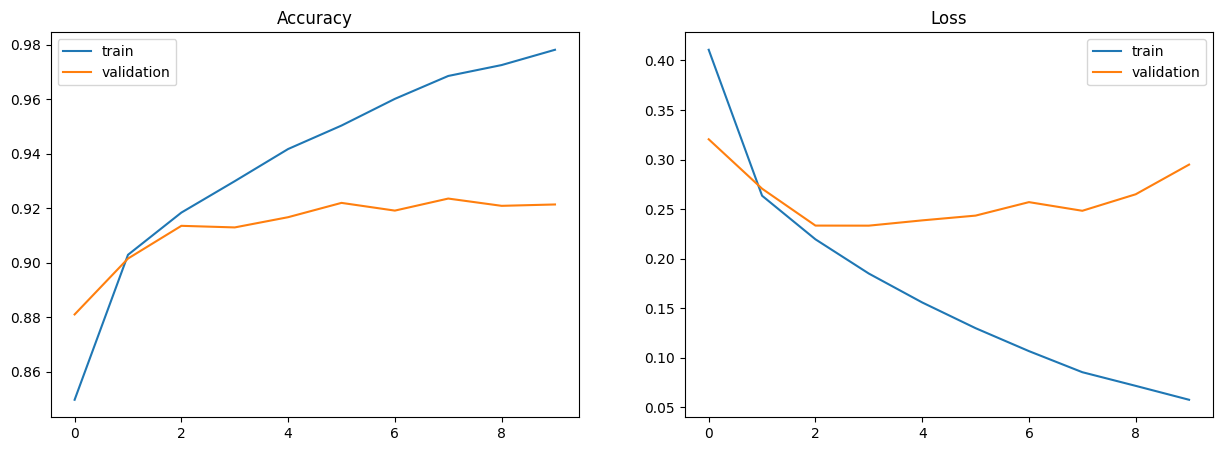

In [14]:
plot_history(history.history)

In [15]:
model.evaluate(x_test, y_test)

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9148 - loss: 0.3378


[0.33778244256973267, 0.9147999882698059]

#Drop out
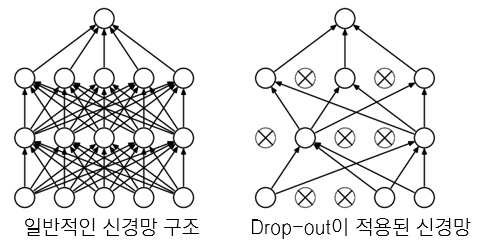

In [16]:
model1 = models.Sequential()
model1.add(layers.Conv2D(32, (3,3), padding='same', activation='relu', input_shape=(28,28,1)))
model1.add(layers.MaxPooling2D((2,2), strides=2))
model1.add(layers.Conv2D(64, (3,3), padding='same', activation='relu'))
model1.add(layers.MaxPooling2D((2,2), strides=2))
model1.add(layers.Conv2D(128, (3,3), padding='same', activation='relu'))
model1.add(layers.Flatten())
model1.add(layers.Dense(128, activation='relu'))
model1.add(layers.Dropout(0.3))
model1.add(layers.Dense(10, activation='softmax'))
model1.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_3 (Conv2D)               │ (None, 28, 28, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 14, 14, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 7, 7, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 6272)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │       802,944 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 896,906 (3.42 MB)

 Trainable params: 896,906 (3.42 MB)

 Non-trainable params: 0 (0.00 B)

In [18]:
model1.compile(loss='sparse_categorical_crossentropy', optimizer='adam', metrics=['accuracy'])

In [19]:
history = model1.fit(x_train, y_train, epochs=10, validation_split=0.2)

Epoch 1/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 11s 5ms/step - accuracy: 0.8301 - loss: 0.4707 - val_accuracy: 0.8917 - val_loss: 0.3012
Epoch 2/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.8910 - loss: 0.2995 - val_accuracy: 0.8978 - val_loss: 0.2768
Epoch 3/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.9095 - loss: 0.2478 - val_accuracy: 0.9103 - val_loss: 0.2433
Epoch 4/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.9195 - loss: 0.2177 - val_accuracy: 0.9118 - val_loss: 0.2409
Epoch 5/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.9290 - loss: 0.1905 - val_accuracy: 0.9180 - val_loss: 0.2206
Epoch 6/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.9368 - loss: 0.1675 - val_accuracy: 0.9215 - val_loss: 0.2173
Epoch 7/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.9461 - loss: 0.1447 - val_accuracy: 0.9215 - val_loss: 0.2285
Epoch 8/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.9505 - loss: 0.1277 -

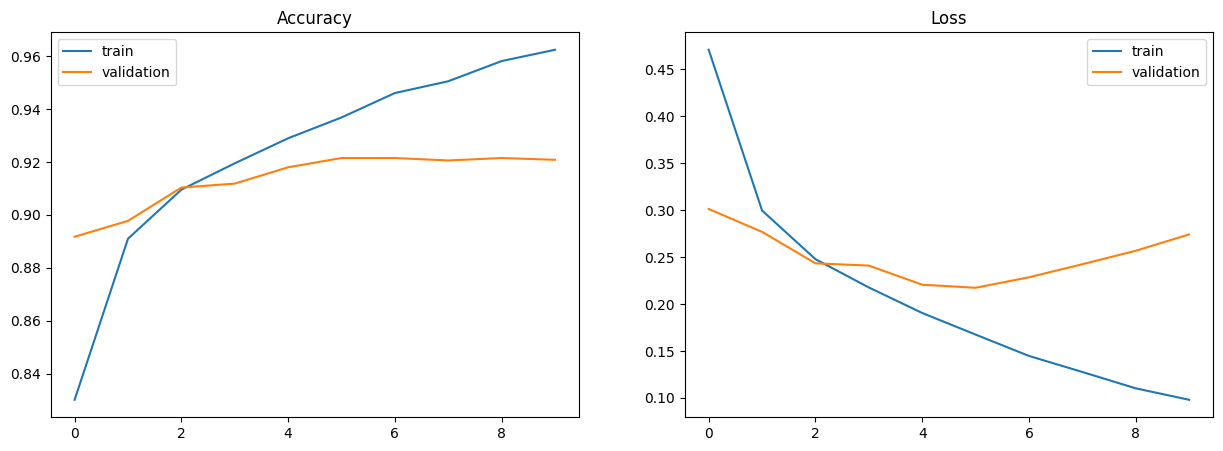

In [20]:
plot_history(history.history)

In [21]:
model1.evaluate(x_test, y_test)

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9163 - loss: 0.3200


[0.31995338201522827, 0.9162999987602234]

## BatchNormalization
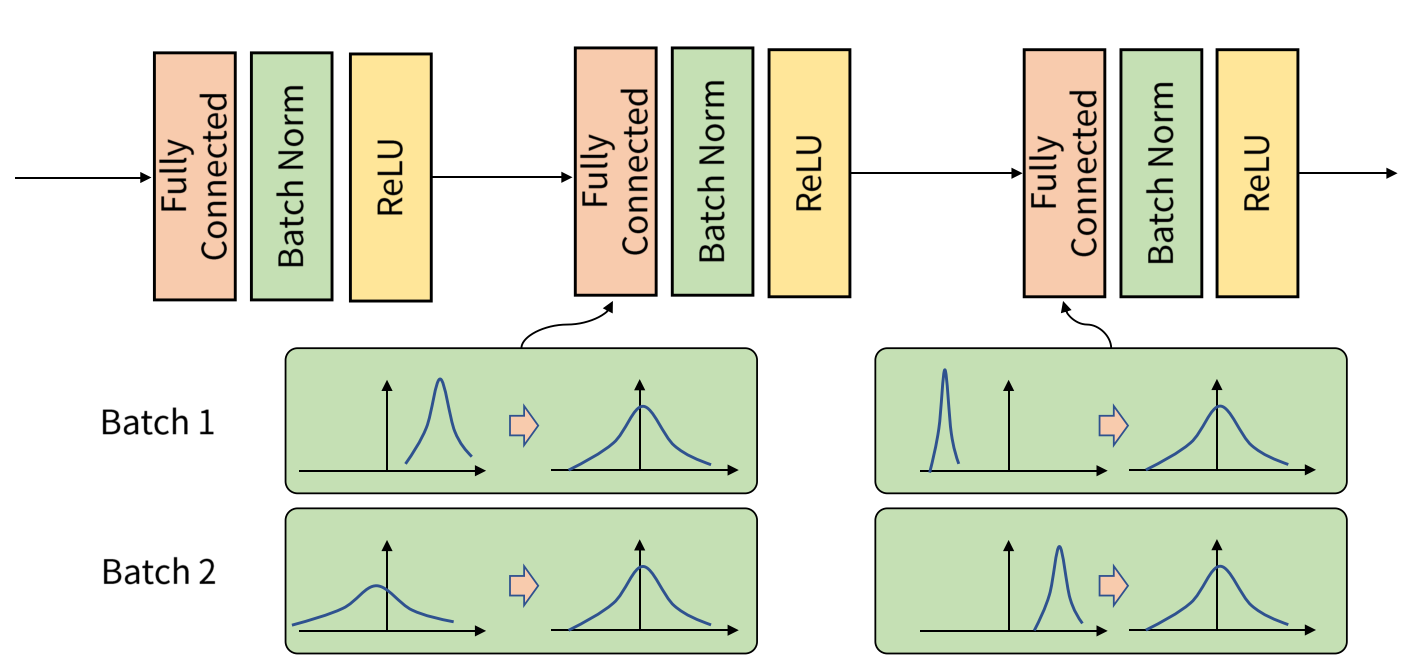

In [22]:
model2 = models.Sequential()
model2.add(layers.Conv2D(32, (3,3), padding='same', activation='relu', input_shape=(28,28,1)))
model2.add(layers.BatchNormalization())
model2.add(layers.MaxPooling2D((2,2), strides=2))
model2.add(layers.Conv2D(64, (3,3), padding='same', activation='relu'))
model2.add(layers.BatchNormalization())
model2.add(layers.MaxPooling2D((2,2), strides=2))
model2.add(layers.Conv2D(128, (3,3), padding='same', activation='relu'))
model2.add(layers.Flatten())
model2.add(layers.Dense(128, activation='relu'))
model2.add(layers.Dropout(0.3))
model2.add(layers.Dense(10, activation='softmax'))
model2.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_6 (Conv2D)               │ (None, 28, 28, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 28, 28, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 14, 14, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 14, 14, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (None, 7, 7, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 6272)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 128)            │       802,944 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 897,290 (3.42 MB)

 Trainable params: 897,098 (3.42 MB)

 Non-trainable params: 192 (768.00 B)

In [24]:
model2.compile(loss='sparse_categorical_crossentropy', optimizer='adam', metrics=['accuracy'])

In [25]:
history = model2.fit(x_train, y_train, epochs=10, validation_split=0.2)

Epoch 1/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 12s 5ms/step - accuracy: 0.8543 - loss: 0.4065 - val_accuracy: 0.8946 - val_loss: 0.2885
Epoch 2/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.9011 - loss: 0.2724 - val_accuracy: 0.8717 - val_loss: 0.3563
Epoch 3/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.9146 - loss: 0.2329 - val_accuracy: 0.9122 - val_loss: 0.2447
Epoch 4/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.9233 - loss: 0.2079 - val_accuracy: 0.9148 - val_loss: 0.2302
Epoch 5/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.9312 - loss: 0.1844 - val_accuracy: 0.9058 - val_loss: 0.2824
Epoch 6/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.9385 - loss: 0.1635 - val_accuracy: 0.9199 - val_loss: 0.2443
Epoch 7/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.9438 - loss: 0.1509 - val_accuracy: 0.9180 - val_loss: 0.2600
Epoch 8/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.9496 - loss: 0.1332 -

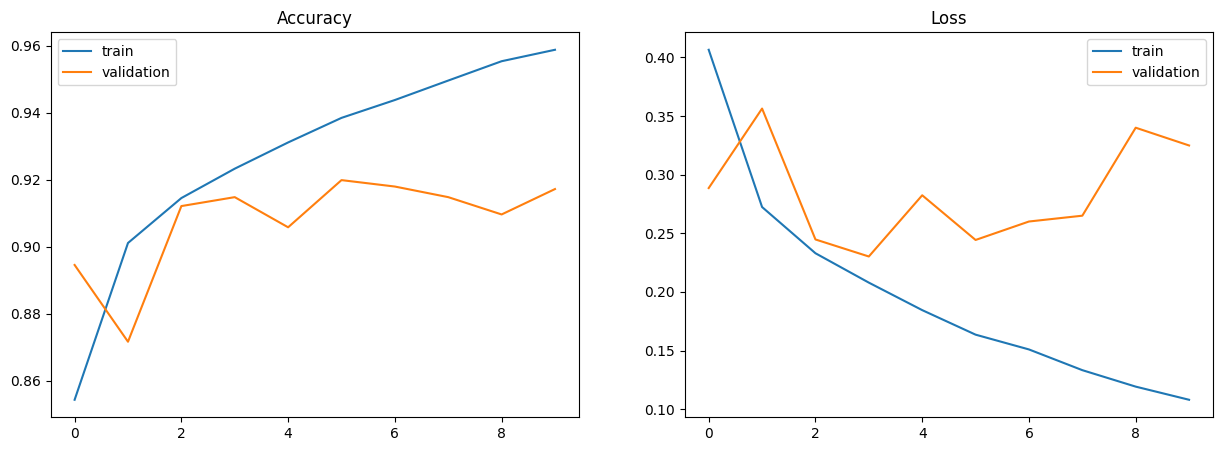

In [26]:
plot_history(history.history)

In [27]:
model2.evaluate(x_test, y_test)

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9087 - loss: 0.3816


[0.38161057233810425, 0.9086999893188477]

#Callback

In [28]:
model3 = models.Sequential()
model3.add(layers.Conv2D(32, (3,3), padding='same', activation='relu', input_shape=(28,28,1)))
model3.add(layers.Dropout(0.3))
model3.add(layers.MaxPooling2D((2,2), strides=2))
model3.add(layers.Conv2D(64, (3,3), padding='same', activation='relu'))
model3.add(layers.MaxPooling2D((2,2), strides=2))
model3.add(layers.Conv2D(128, (3,3), padding='same', activation='relu'))
model3.add(layers.Flatten())
model3.add(layers.Dense(128, activation='relu'))
model3.add(layers.Dropout(0.3))
model3.add(layers.Dense(10, activation='softmax'))
model3.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_9 (Conv2D)               │ (None, 28, 28, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 28, 28, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_10 (Conv2D)              │ (None, 14, 14, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_7 (MaxPooling2D)  │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_11 (Conv2D)              │ (None, 7, 7, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_3 (Flatten)             │ (None, 6272)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 128)            │       802,944 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 896,906 (3.42 MB)

 Trainable params: 896,906 (3.42 MB)

 Non-trainable params: 0 (0.00 B)

In [30]:
model3.compile(loss='sparse_categorical_crossentropy', optimizer='adam', metrics=['accuracy'])

In [31]:
checkpoint_cb = keras.callbacks.ModelCheckpoint('best_model.h5')
history = model3.fit(x_train, y_train, epochs=10,
                     validation_split=0.2,
                     callbacks=[checkpoint_cb])

Epoch 1/10
1490/1500 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7607 - loss: 0.6570

1500/1500 ━━━━━━━━━━━━━━━━━━━━ 11s 5ms/step - accuracy: 0.8306 - loss: 0.4712 - val_accuracy: 0.8702 - val_loss: 0.3517
Epoch 2/10
1492/1500 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8858 - loss: 0.3140

1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.8904 - loss: 0.3033 - val_accuracy: 0.8985 - val_loss: 0.2858
Epoch 3/10
1486/1500 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9044 - loss: 0.2574

1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.9060 - loss: 0.2559 - val_accuracy: 0.9052 - val_loss: 0.2523
Epoch 4/10
1493/1500 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9173 - loss: 0.2250

1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.9181 - loss: 0.2256 - val_accuracy: 0.9111 - val_loss: 0.2430
Epoch 5/10
1497/1500 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9262 - loss: 0.2000

...

1500/1500 ━━━━━━━━━━━━━━━━━━━━ 11s 4ms/step - accuracy: 0.9341 - loss: 0.1774 - val_accuracy: 0.9188 - val_loss: 0.2262
Epoch 7/10
1490/1500 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9399 - loss: 0.1596

1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.9396 - loss: 0.1613 - val_accuracy: 0.9178 - val_loss: 0.2295
Epoch 8/10
1486/1500 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9471 - loss: 0.1417

1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.9471 - loss: 0.1428 - val_accuracy: 0.9227 - val_loss: 0.2256
Epoch 9/10
1493/1500 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9518 - loss: 0.1272

1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.9506 - loss: 0.1298 - val_accuracy: 0.9227 - val_loss: 0.2350
Epoch 10/10
1489/1500 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9581 - loss: 0.1091

1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.9554 - loss: 0.1165 - val_accuracy: 0.9221 - val_loss: 0.2299


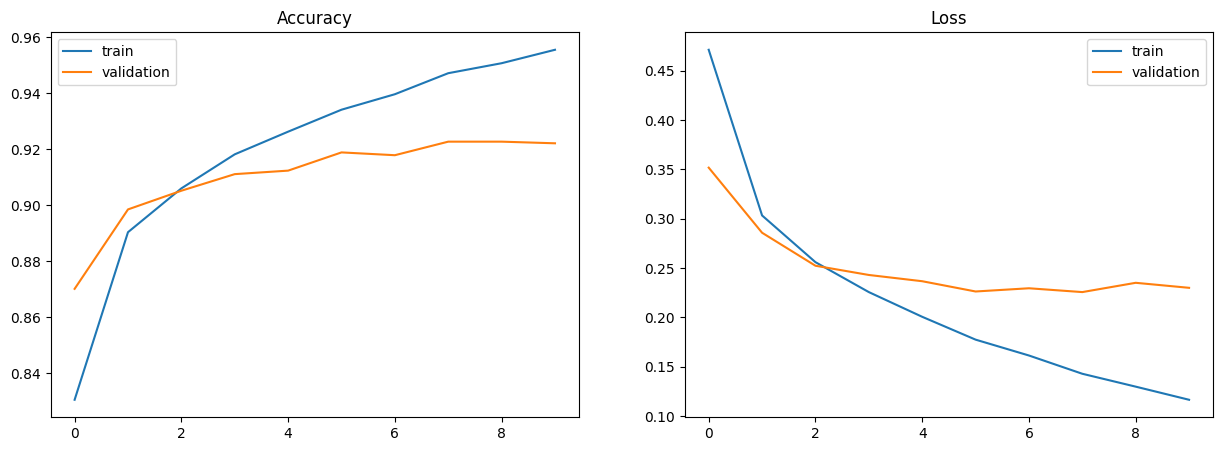

In [32]:
plot_history(history.history)

In [33]:
model3.evaluate(x_test, y_test)

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9193 - loss: 0.2481


[0.2481229454278946, 0.9193000197410583]

In [34]:
model4 = models.Sequential()
model4.add(layers.Conv2D(32, (3,3), padding='same', activation='relu', input_shape=(28,28,1)))
model4.add(layers.Dropout(0.3))
model4.add(layers.MaxPooling2D((2,2), strides=2))
model4.add(layers.Conv2D(64, (3,3), padding='same', activation='relu'))
model4.add(layers.MaxPooling2D((2,2), strides=2))
model4.add(layers.Conv2D(128, (3,3), padding='same', activation='relu'))
model4.add(layers.Flatten())
model4.add(layers.Dense(128, activation='relu'))
model4.add(layers.Dropout(0.3))
model4.add(layers.Dense(10, activation='softmax'))
model4.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_12 (Conv2D)              │ (None, 28, 28, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 28, 28, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_8 (MaxPooling2D)  │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_13 (Conv2D)              │ (None, 14, 14, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_9 (MaxPooling2D)  │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_14 (Conv2D)              │ (None, 7, 7, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_4 (Flatten)             │ (None, 6272)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 128)            │       802,944 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 896,906 (3.42 MB)

 Trainable params: 896,906 (3.42 MB)

 Non-trainable params: 0 (0.00 B)

In [35]:
model4.compile(loss='sparse_categorical_crossentropy', optimizer='adam', metrics=['accuracy'])

In [36]:
checkpoint_cb = keras.callbacks.ModelCheckpoint('best_model.h5')
earlystopping_cb = keras.callbacks.EarlyStopping(patience=3,
                              restore_best_weights=True)
history = model4.fit(x_train, y_train, epochs=10,
                     validation_split=0.2,
                     callbacks=[checkpoint_cb, earlystopping_cb])

Epoch 1/10
1498/1500 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7610 - loss: 0.6577

1500/1500 ━━━━━━━━━━━━━━━━━━━━ 11s 5ms/step - accuracy: 0.8286 - loss: 0.4704 - val_accuracy: 0.8830 - val_loss: 0.3267
Epoch 2/10
1493/1500 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8852 - loss: 0.3177

1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.8895 - loss: 0.3055 - val_accuracy: 0.9000 - val_loss: 0.2758
Epoch 3/10
1494/1500 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9038 - loss: 0.2623

1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.9045 - loss: 0.2612 - val_accuracy: 0.9094 - val_loss: 0.2489
Epoch 4/10
1493/1500 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9173 - loss: 0.2238

1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.9151 - loss: 0.2305 - val_accuracy: 0.9154 - val_loss: 0.2274
Epoch 5/10
1497/1500 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9250 - loss: 0.2028

...

1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.9310 - loss: 0.1847 - val_accuracy: 0.9198 - val_loss: 0.2184
Epoch 7/10
1495/1500 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9379 - loss: 0.1637

1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.9368 - loss: 0.1670 - val_accuracy: 0.9157 - val_loss: 0.2297
Epoch 8/10
1491/1500 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9436 - loss: 0.1490

1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.9433 - loss: 0.1510 - val_accuracy: 0.9236 - val_loss: 0.2167
Epoch 9/10
1487/1500 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9516 - loss: 0.1310

1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.9483 - loss: 0.1375 - val_accuracy: 0.9232 - val_loss: 0.2339
Epoch 10/10
1491/1500 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9546 - loss: 0.1211

1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.9527 - loss: 0.1255 - val_accuracy: 0.9252 - val_loss: 0.2378


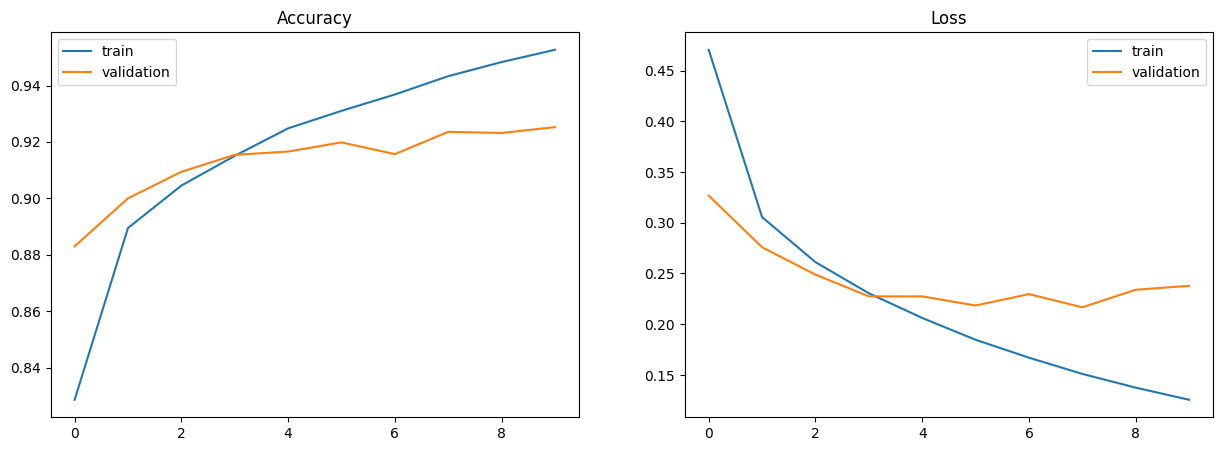

In [37]:
plot_history(history.history)

In [38]:
pred=model4.predict(x_test[0:25])
print(np.round(pred, decimals=3))

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 589ms/step
[[0.    0.    0.    0.    0.    0.    0.    0.    0.    1.   ]
 [0.    0.    0.999 0.    0.    0.    0.001 0.    0.    0.   ]
 [0.    1.    0.    0.    0.    0.    0.    0.    0.    0.   ]
 [0.    1.    0.    0.    0.    0.    0.    0.    0.    0.   ]
 [0.182 0.    0.017 0.    0.013 0.    0.788 0.    0.    0.   ]
 [0.    1.    0.    0.    0.    0.    0.    0.    0.    0.   ]
 [0.    0.    0.008 0.    0.991 0.    0.    0.    0.    0.   ]
 [0.    0.    0.002 0.    0.07  0.    0.927 0.    0.    0.   ]
 [0.    0.    0.    0.    0.    1.    0.    0.    0.    0.   ]
 [0.    0.    0.    0.    0.    0.    0.    1.    0.    0.   ]
 [0.    0.    0.005 0.    0.992 0.    0.003 0.    0.    0.   ]
 [0.    0.    0.    0.    0.    0.999 0.    0.001 0.    0.   ]
 [0.    0.    0.    0.    0.    0.101 0.    0.894 0.005 0.   ]
 [0.    0.    0.    1.    0.    0.    0.    0.    0.    0.   ]
 [0.    0.    0.153 0.    0.84  0.    0.007 0.    0.    0.   ]
 [0.    1.    0.

In [39]:
np.argmax(pred,axis=1)

array([9, 2, 1, 1, 6, 1, 4, 6, 5, 7, 4, 5, 7, 3, 4, 1, 2, 4, 8, 0, 2, 5,
       7, 5, 1])

In [40]:
print(y_test[0:25])

[9 2 1 1 6 1 4 6 5 7 4 5 7 3 4 1 2 4 8 0 2 5 7 9 1]


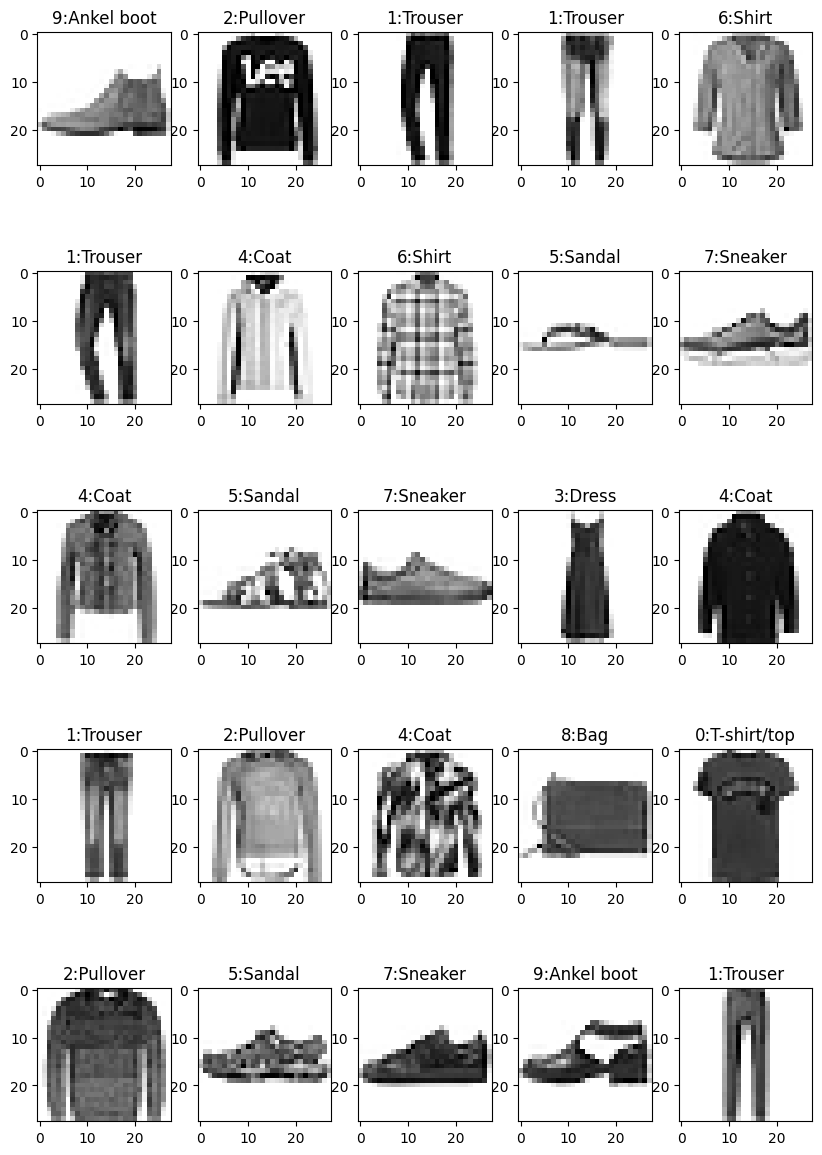

In [41]:
fig, axs = plt.subplots(5, 5, figsize=(10,15))
for i in range(5):
  for j in range(5):
    axs[i, j].set_title('{}:{}'.format(y_test[i*5+j], items[y_test[i*5+j]]))
    axs[i, j].imshow(x_test2d[i*5+j], cmap='gray_r')
plt.show()

## CNN의 시각화

In [42]:
utils.plot_model(model5, show_shapes=True, to_file='fmist.png')

NameError: name 'model5' is not defined

### 학습된 Conv층 가져오기

In [ ]:
model5.layers

In [ ]:
conv=model5.layers[0]
print(conv.weights[0].shape, conv.weights[1].shape)

In [ ]:
weights = conv.weights[0].numpy()
print(weights.shape)
print(weights)

In [ ]:
plt.hist(weights.reshape(-1, 1))
plt.xlabel('weights')
plt.ylabel('count')
plt.show()

In [ ]:
weights[:, :, 0, 0]

In [ ]:
weights[:, :, 0, 1]

In [ ]:
fig, axs = plt.subplots(4, 8, figsize=(12, 6))
for i in range(4):
  for j in range(8):
    axs[i, j].imshow(weights[:, :, 0, i*4+j], vmin=-0.5, vmax=0.5)
    axs[i, j].axis('off')
plt.show()

In [ ]:
init_model = keras.Sequential()
init_model.add(layers.Conv2D(32, (3,3), activation='relu',
                             padding='same', input_shape=(28,28,1)))
init_model.summary()

In [ ]:
new_conv=init_model.layers[0]
print(new_conv.weights[0].shape, new_conv.weights[1].shape)

In [ ]:
new_weights = new_conv.weights[0].numpy()
print(new_weights.shape)
print(new_weights)

In [ ]:
plt.hist(new_weights.reshape(-1, 1))
plt.xlabel('weights')
plt.ylabel('count')
plt.show()

In [ ]:
fig, axs = plt.subplots(4, 8, figsize=(12, 6))
for i in range(4):
  for j in range(8):
    axs[i, j].imshow(new_weights[:, :, 0, i*4+j], vmin=-0.5, vmax=0.5)
    axs[i, j].axis('off')
plt.show()

### 필터를 거친 이미지 확인하기

In [ ]:
conv1 = keras.Model(model5.input, model5.layers[0].output)
conv1.summary()

In [ ]:
plt.imshow(x_train2d[0])
plt.show()

In [ ]:
feature_map1 = conv1.predict(x_train[0:1])
print(feature_map1.shape)

In [ ]:
feature_map1[0, :, :, 0]

In [ ]:
feature_map1[0, :, :, 1]

In [ ]:
fig, axs = plt.subplots(4, 8, figsize=(12, 6))
for i in range(4):
  for j in range(8):
    axs[i, j].imshow(feature_map1[0, :, :, i*4+j])
    axs[i, j].axis('off')
plt.show()

In [ ]:
model5.layers

In [ ]:
conv2 = keras.Model(model5.input, model5.layers[2].output)
conv2.summary()

In [ ]:
feature_map2 = conv2.predict(x_train[0:1])
print(feature_map2.shape)

In [ ]:
fig, axs = plt.subplots(4, 8, figsize=(12, 6))
for i in range(4):
  for j in range(8):
    axs[i, j].imshow(feature_map2[0, :, :, i*4+j])
    axs[i, j].axis('off')
plt.show()

In [ ]:
conv3 = keras.Model(model5.input, model5.layers[3].output)
conv3.summary()

In [ ]:
feature_map3 = conv3.predict(x_train[0:1])
print(feature_map3.shape)

In [ ]:
feature_map3[0,:,:,0]

In [ ]:
fig, axs = plt.subplots(8, 8, figsize=(12, 12))
for i in range(8):
  for j in range(8):
    axs[i, j].imshow(feature_map3[0, :, :, i*4+j])
    axs[i, j].axis('off')
plt.show()